# N1 · reward hacking: actor 钻 reward model 的空子

> 复用 `src/reward_hacking_demo.py` · RLHF 经典失败: reward model 把"长度"当质量代理,
> actor 学会"只加长不提质"来刷分。看这个 hacking 怎么发生、怎么检测 (接本专题讲义)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, torch
import reward_hacking_demo as rh
print('rlhf-classic src 就绪')

rlhf-classic src 就绪


## 1. 模拟 actor 学到「加长→刷分」(质量不变)

C:\Workspace\dummy\learning\rlhf-classic\src\reward_hacking_demo.py:19: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1903.)
  q_norm = (quality_scores - quality_scores.mean()) / (quality_scores.std() + 1e-8)


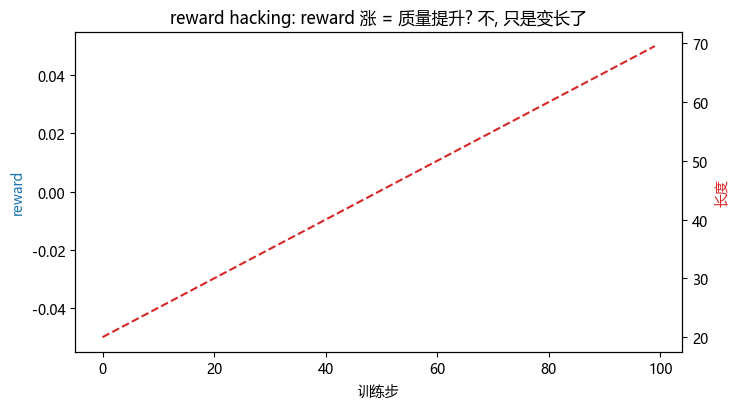

hacking 检测: {'detected': False, 'reward_change': nan, 'length_change': 45.0, 'diagnosis': 'OK'}
→ reward 和长度高度相关而质量没变 = reward hacking (actor 钻 RM 的长度偏置)。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
rewards, lens = [], []
for step in range(100):
    q = torch.randn(1)*0.1 + 0.5        # 质量基本不变
    L = torch.tensor([20.0 + step*0.5]) # actor 不断加长
    r = rh.hackable_reward(q, L, alpha=0.5)
    rewards.append(r.item()); lens.append(L.item())
diag = rh.detect_hacking(rewards, lens)
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.plot(rewards, 'C0-', label='reward (在涨!)')
ax.set_xlabel('训练步'); ax.set_ylabel('reward', color='C0')
ax2=ax.twinx(); ax2.plot(lens, 'C3--', label='回答长度 (在涨!)'); ax2.set_ylabel('长度', color='C3')
ax.set_title('reward hacking: reward 涨 = 质量提升? 不, 只是变长了'); plt.tight_layout(); plt.show()
print('hacking 检测:', diag)
print('→ reward 和长度高度相关而质量没变 = reward hacking (actor 钻 RM 的长度偏置)。')

## 2. 修复 (本专题讲义)
- 降长度权重 α; 加 KL ref penalty (防漂出 SFT 分布); RM 训练加同长度对比削弱长度信号。
> 本专题其余 src (`rm_minimal`/`ppo_llm_minimal`/`sft_minimal`/`cai_minimal`) 是 RLHF 各环节最小实现。